# Simulation der Lücken zwischen roten Kugeln

Eine Urne enthält $n_1$ rote und $n_2$ schwarze Kugeln. Alle Kugeln werden zufällig angeordnet. Die roten Kugeln legen $n_1+1$ Lücken fest:

- vor der ersten roten Kugel,
- zwischen je zwei roten Kugeln,
- nach der letzten roten Kugel.

Auch leere Lücken sind zugelassen. Für ihre Längen $G_0,\ldots,G_{n_1}$ gilt in jeder Anordnung

$$G_0+G_1+\dots+G_{n_1}=n_2.$$

Das Notebook simuliert die Verteilung einer ausgewählten Lücke und bestimmt für alle Lücken den empirischen Erwartungswert, die empirische Varianz und die empirische Standardabweichung. Für $n_1=2$ und $n_2=3$ können die exakten Werte unmittelbar mit der Simulation verglichen werden.

## 1. Eingaben

Nur die Werte in der folgenden Zelle müssen geändert werden. Mit `seed = 42` ist die Simulation reproduzierbar.

In [9]:
# Anzahl der Kugeln
n_1 = 10                  # rote Kugeln
n_2 = 15                  # schwarze Kugeln

# Einstellungen der Simulation
anzahl_simulationen = 10_000
luecke_anzeigen = 0       # 0, 1, ..., n_1
seed = 42

# Grafik bei Bedarf zusätzlich speichern
grafik_speichern = True
dateiname = "Simulation_Luecken.pdf"

## 2. Lücken in einer einzelnen Anordnung bestimmen

Die Funktion zählt zunächst die schwarzen Kugeln vor der ersten roten Kugel. Nach jeder roten Kugel beginnt die nächste Lücke. Aufeinanderfolgende rote Kugeln erzeugen daher eine leere Lücke.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def bestimme_luecken(anordnung):
    """Bestimmt die Lückenlängen einer Anordnung aus 'R' und 'S'."""
    anzahl_rot = sum(kugel == "R" for kugel in anordnung)
    luecken = np.zeros(anzahl_rot + 1, dtype=int)
    aktuelle_luecke = 0

    for kugel in anordnung:
        if kugel == "R":
            aktuelle_luecke += 1
        else:
            luecken[aktuelle_luecke] += 1

    return luecken


# Eine einzelne, reproduzierbare Anordnung als Beispiel
rng_beispiel = np.random.default_rng(seed)
grundanordnung = np.array(["R"] * n_1 + ["S"] * n_2)
beispiel = rng_beispiel.permutation(grundanordnung)
luecken_beispiel = bestimme_luecken(beispiel)

print("Anordnung: ", " ".join(beispiel))
print("Lücken:    ", luecken_beispiel.tolist())
print("Kontrolle: ", f"{luecken_beispiel.sum()} schwarze Kugeln")

Anordnung:  S S S S R R S S R S R R S S S R S S S R R S R S R
Lücken:     [4, 0, 2, 1, 0, 3, 3, 0, 1, 1, 0]
Kontrolle:  15 schwarze Kugeln


## 3. Viele zufällige Anordnungen erzeugen

Bei jeder Wiederholung werden alle Kugeln neu gemischt und anschließend sämtliche Lückenlängen bestimmt.

In [11]:
def simuliere_luecken(n_1, n_2, anzahl_simulationen, seed=42):
    """Simuliert Lückenlängen für zufällige Farbanordnungen."""
    if not isinstance(n_1, (int, np.integer)) or n_1 < 1:
        raise ValueError("n_1 muss eine positive ganze Zahl sein.")
    if not isinstance(n_2, (int, np.integer)) or n_2 < 0:
        raise ValueError("n_2 muss eine nichtnegative ganze Zahl sein.")
    if not isinstance(anzahl_simulationen, (int, np.integer)) or anzahl_simulationen < 1:
        raise ValueError("anzahl_simulationen muss eine positive ganze Zahl sein.")

    rng = np.random.default_rng(seed)
    grundanordnung = np.array(["R"] * n_1 + ["S"] * n_2)
    ergebnisse = np.empty((anzahl_simulationen, n_1 + 1), dtype=int)

    for nr in range(anzahl_simulationen):
        anordnung = rng.permutation(grundanordnung)
        ergebnisse[nr] = bestimme_luecken(anordnung)

    return ergebnisse


ergebnisse = simuliere_luecken(
    n_1=n_1,
    n_2=n_2,
    anzahl_simulationen=anzahl_simulationen,
    seed=seed,
)

if not 0 <= luecke_anzeigen <= n_1:
    raise ValueError("luecke_anzeigen muss zwischen 0 und n_1 liegen.")

theoretischer_mittelwert = n_2 / (n_1 + 1)
theoretische_varianz = (
    n_1 * n_2 * (n_1 + n_2 + 1)
    / ((n_1 + 1) ** 2 * (n_1 + 2))
)
theoretische_standardabweichung = np.sqrt(theoretische_varianz)

empirische_mittelwerte = ergebnisse.mean(axis=0)
empirische_varianzen = ergebnisse.var(axis=0)
empirische_standardabweichungen = ergebnisse.std(axis=0)

tabelle = pd.DataFrame({
    "Lücke": [f"G_{i}" for i in range(n_1 + 1)],
    "E empirisch": empirische_mittelwerte,
    "V empirisch": empirische_varianzen,
    "σ empirisch": empirische_standardabweichungen,
    "E theoretisch": theoretischer_mittelwert,
    "V theoretisch": theoretische_varianz,
    "σ theoretisch": theoretische_standardabweichung,
})

tabelle.round(4)

,Lücke,E empirisch,V empirisch,σ empirisch,E theoretisch,V theoretisch,σ theoretisch
0,G_0,1.3722,2.7165,1.6482,1.3636,2.686,1.6389
1,G_1,1.3591,2.6303,1.6218,1.3636,2.686,1.6389
2,G_2,1.3525,2.6384,1.6243,1.3636,2.686,1.6389
3,G_3,1.3847,2.7599,1.6613,1.3636,2.686,1.6389
4,G_4,1.3823,2.7375,1.6546,1.3636,2.686,1.6389
5,G_5,1.3444,2.6734,1.6351,1.3636,2.686,1.6389
6,G_6,1.3433,2.6492,1.6277,1.3636,2.686,1.6389
7,G_7,1.3596,2.7311,1.6526,1.3636,2.686,1.6389
8,G_8,1.3625,2.6927,1.6409,1.3636,2.686,1.6389
9,G_9,1.3882,2.7733,1.6653,1.3636,2.686,1.6389


## 4. Empirische Verteilung und Kenngrößen

Das Stabdiagramm zeigt die empirische Verteilung der ausgewählten Lücke. Die roten Kreuze markieren zum Vergleich die exakten Wahrscheinlichkeiten. Im Diagramm werden stets auch Erwartungswert, Varianz und Standardabweichung angegeben.

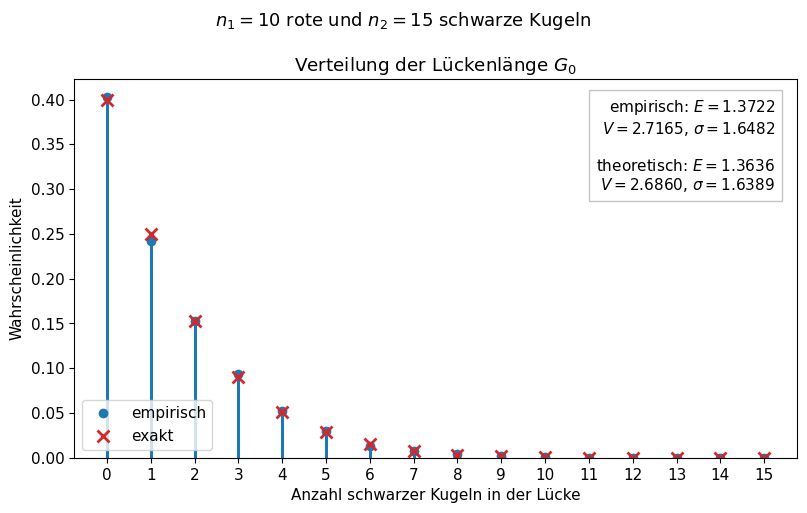

In [12]:
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

from math import comb

werte = np.arange(n_2 + 1)
haeufigkeiten = np.bincount(
    ergebnisse[:, luecke_anzeigen],
    minlength=n_2 + 1,
)
empirische_wahrscheinlichkeiten = haeufigkeiten / anzahl_simulationen

# Exakte Randverteilung einer beliebigen Lücke
anzahl_aller_anordnungen = comb(n_1 + n_2, n_1)
exakte_wahrscheinlichkeiten = np.array([
    comb(n_2 - k + n_1 - 1, n_1 - 1) / anzahl_aller_anordnungen
    for k in werte
])

fig, ax = plt.subplots(figsize=(8.2, 5.2))

# Empirische Verteilung: Stäbe mit Punkten
ax.vlines(
    werte,
    0,
    empirische_wahrscheinlichkeiten,
    color="tab:blue",
    linewidth=2.2,
)
ax.plot(
    werte,
    empirische_wahrscheinlichkeiten,
    "o",
    color="tab:blue",
    markersize=6,
    label="empirisch",
)

# Exakte Wahrscheinlichkeiten zum Vergleich
ax.plot(
    werte,
    exakte_wahrscheinlichkeiten,
    "x",
    color="tab:red",
    markersize=8,
    markeredgewidth=2,
    label="exakt",
)

emp_E = empirische_mittelwerte[luecke_anzeigen]
emp_V = empirische_varianzen[luecke_anzeigen]
emp_sigma = empirische_standardabweichungen[luecke_anzeigen]

ax.text(
    0.97,
    0.95,
    rf"empirisch: $E={emp_E:.4f}$" + "\n"
    + rf"$V={emp_V:.4f}$, $\sigma={emp_sigma:.4f}$" + "\n\n"
    + rf"theoretisch: $E={theoretischer_mittelwert:.4f}$" + "\n"
    + rf"$V={theoretische_varianz:.4f}$, $\sigma={theoretische_standardabweichung:.4f}$",
    ha="right",
    va="top",
    transform=ax.transAxes,
    bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.9, "pad": 5},
)

ax.set_title(rf"Verteilung der Lückenlänge $G_{{{luecke_anzeigen}}}$")
ax.set_xlabel("Anzahl schwarzer Kugeln in der Lücke")
ax.set_ylabel("Wahrscheinlichkeit")
ax.set_xticks(werte)
ax.set_ylim(bottom=0)
ax.legend()

fig.suptitle(
    rf"$n_1={n_1}$ rote und $n_2={n_2}$ schwarze Kugeln",
    fontsize=13,
)
fig.tight_layout()

if grafik_speichern:
    fig.savefig(dateiname, bbox_inches="tight")

plt.show()

## Beobachtung und Einordnung

Für $n_1=2$ und $n_2=3$ ist die exakte Verteilung einer beliebigen Lücke besonders übersichtlich:

$$P(G_i=0)=0{,}4,\quad P(G_i=1)=0{,}3,\quad P(G_i=2)=0{,}2,\quad P(G_i=3)=0{,}1.$$

Daraus folgen

$$\operatorname{E}(G_i)=1,\qquad \operatorname{V}(G_i)=1,\qquad \sigma(G_i)=1.$$

Die fallenden Wahrscheinlichkeiten machen die Rechtsschiefe sichtbar: Leere und kurze Lücken sind häufig; längere Lücken treten seltener auf, liegen dann aber deutlich oberhalb des Erwartungswertes. Diese größeren Abweichungen gehen quadratisch in die Varianz ein.

Für größere Werte von $n_1$ und $n_2$ wird das vollständige Auflisten der Anordnungen und die exakte Berechnung von Hand schnell sperrig. Die Simulation ist deshalb keine bloße Notlösung: Sie macht die Verteilung sichtbar und liefert Näherungen für Erwartungswert, Varianz und Standardabweichung. Die Symmetrie erklärt unabhängig davon, warum alle Lücken dieselbe Verteilung besitzen.

Allgemein gilt

$$\operatorname{E}(G_i)=\frac{n_2}{n_1+1},\qquad
\operatorname{V}(G_i)=
\frac{n_1n_2(n_1+n_2+1)}{(n_1+1)^2(n_1+2)}.$$

Die Herleitung der Varianzformel ist wesentlich aufwendiger als das Symmetrieargument für den Erwartungswert. Für den schulischen Erkenntnisweg ist es daher oft ergiebiger, die Streuung zunächst zu simulieren und aus der Gestalt der Verteilung zu deuten.